# 🌫️ Karachi AQI Predictor — Exploratory Data Analysis

**Author:** Hamza Ali  
**Project:** End-to-end serverless AQI forecasting system  
**Stack:** Open-Meteo API · BigQuery Feature Store · GitHub Actions · Streamlit  
**Goal:** Forecast Karachi's Air Quality Index (AQI) at 24h, 48h, and 72h horizons

---

This notebook performs a comprehensive exploratory data analysis (EDA) of the feature dataset stored in BigQuery. It covers:

1. Data loading and schema inspection  
2. Descriptive statistics  
3. Missing value analysis  
4. AQI distribution analysis  
5. Temporal patterns (hourly, daily, monthly)  
6. Pollutant correlations  
7. Feature engineering validation  
8. Forecast feature coverage  
9. Target variable analysis  
10. Key insights and conclusions

## Imports & setup
We load plotting libraries and the Python GCP client for BigQuery. Ensure Google application credentials are authenticated for GCP access in your environment or `.env` file.

In [1]:
# ── Imports ────────────────────────────────────────────────────────────────────
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from dotenv import load_dotenv
from google.cloud import bigquery

warnings.filterwarnings("ignore")
load_dotenv()

# Plot style
plt.rcParams.update({
    "figure.facecolor": "#0a0e1a",
    "axes.facecolor":   "#111827",
    "axes.edgecolor":   "#1e2d4a",
    "axes.labelcolor":  "#94a3b8",
    "xtick.color":      "#64748b",
    "ytick.color":      "#64748b",
    "text.color":       "#e2e8f0",
    "grid.color":       "#1e2d4a",
    "grid.linestyle":   "--",
    "grid.alpha":       0.5,
    "font.family":      "monospace",
    "figure.dpi":       120,
})

ACCENT   = "#3b82f6"
ACCENT2  = "#06b6d4"
GOOD     = "#22c55e"
MODERATE = "#eab308"
BAD      = "#ef4444"
PURPLE   = "#a855f7"

print("✅ Imports ready")

✅ Imports ready


## Load data
This cell queries all rows from the `aqi_features.features` table in BigQuery, parses `timestamp` with timezone localization, and sorts the dataset into chronological order before viewing its structural contents below.

In [3]:
# ── Load data from BigQuery ─────────────────────────────────────────────────
client = bigquery.Client(project="aqi-predictor-497110")

query = """
    SELECT *
    FROM `aqi-predictor-497110.aqi_features.features`
    ORDER BY timestamp ASC
"""

df = client.query(query).to_dataframe()
df['timestamp'] = pd.to_datetime(df['timestamp'], utc=True)
df = df.sort_values('timestamp').reset_index(drop=True)

print(f" Loaded {len(df):,} rows × {len(df.columns)} columns")
print(f" Date range: {df['timestamp'].min().date()} → {df['timestamp'].max().date()}")
print(f" AQI range: {df['aqi'].min():.1f} → {df['aqi'].max():.1f}")

 Loaded 2,402 rows × 45 columns
 Date range: 2026-01-29 → 2026-05-24
 AQI range: 14.6 → 163.6


## 1. Dataset Schema & Overview

In [4]:
# ── Schema inspection ───────────────────────────────────────────────────────
print("=" * 60)
print(f"{'COLUMN':<30} {'DTYPE':<15} {'NON-NULL':>10}")
print("=" * 60)
for col in df.columns:
    non_null = df[col].notna().sum()
    print(f"{col:<30} {str(df[col].dtype):<15} {non_null:>10,}")

print("=" * 60)
print(f"\nTotal rows    : {len(df):,}")
print(f"Total columns : {len(df.columns)}")
print(f"Memory usage  : {df.memory_usage(deep=True).sum() / 1024:.1f} KB")

COLUMN                         DTYPE             NON-NULL
timestamp                      datetime64[us, UTC]      2,402
pm25                           float64              2,402
pm10                           float64              2,402
o3                             float64              2,402
no2                            float64              2,402
so2                            float64              2,402
co                             float64              2,402
temperature                    float64              2,401
humidity                       float64              2,401
wind_speed                     float64              2,401
aqi                            float64              2,402
hour_of_day                    Int64                2,402
day_of_week                    Int64                2,402
month                          Int64                2,402
hour_sin                       float64              2,402
hour_cos                       float64              2,402
dow_sin   

## Distributions
Histogram + KDE plots reveal skewness and outliers. If a variable is heavily skewed consider log or quantile transforms before modeling.

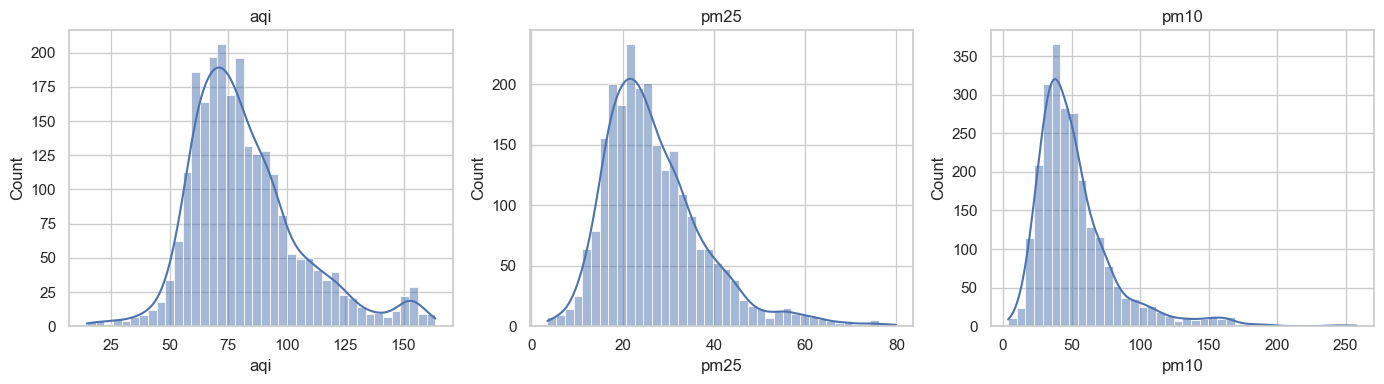

In [5]:
# Cell 4: Distribution plots for core variables
cols = ['aqi', 'pm25', 'pm10']
plt.figure(figsize=(14,4))
for i, c in enumerate(cols, 1):
    plt.subplot(1, 3, i)
    sns.histplot(df[c].dropna(), kde=True, bins=40)
    plt.title(c)
plt.tight_layout()

## 2. Descriptive Statistics

In [5]:
# ── Descriptive statistics ──────────────────────────────────────────────────
pollutant_cols = ['aqi', 'pm25', 'pm10', 'o3', 'no2', 'so2', 'co',
                  'temperature', 'humidity', 'wind_speed']

desc = df[pollutant_cols].describe().T
desc['cv%'] = (desc['std'] / desc['mean'] * 100).round(1)
desc = desc[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max', 'cv%']]
desc = desc.round(3)

print("Descriptive Statistics — Core Features")
print("=" * 90)
print(desc.to_string())
print("=" * 90)
print("\nCV% = Coefficient of Variation (higher = more volatile)")

Descriptive Statistics — Core Features
              count     mean      std      min      25%      50%      75%       max   cv%
aqi          2402.0   82.352   23.980   14.583   66.035   77.918   93.691   163.599  29.1
pm25         2402.0   26.929   11.032    3.500   19.300   24.900   32.400    79.900  41.0
pm10         2402.0   52.705   30.051    3.700   34.100   45.150   61.700   258.000  57.0
o3           2402.0   81.835   39.705    0.000   51.000   75.000  112.000   203.000  48.5
no2          2402.0   20.293   16.032    0.000    8.200   16.300   27.900   116.600  79.0
so2          2402.0   14.502    6.646    3.500    9.900   13.300   17.400    47.200  45.8
co           2402.0  492.277  304.141  116.000  280.000  407.000  602.000  2589.000  61.8
temperature  2401.0   25.549    3.900   13.900   23.000   25.400   28.200    37.100  15.3
humidity     2401.0   67.032   19.819   10.000   53.000   69.000   84.000   100.000  29.6
wind_speed   2401.0   10.095    3.939    0.200    7.400    9.

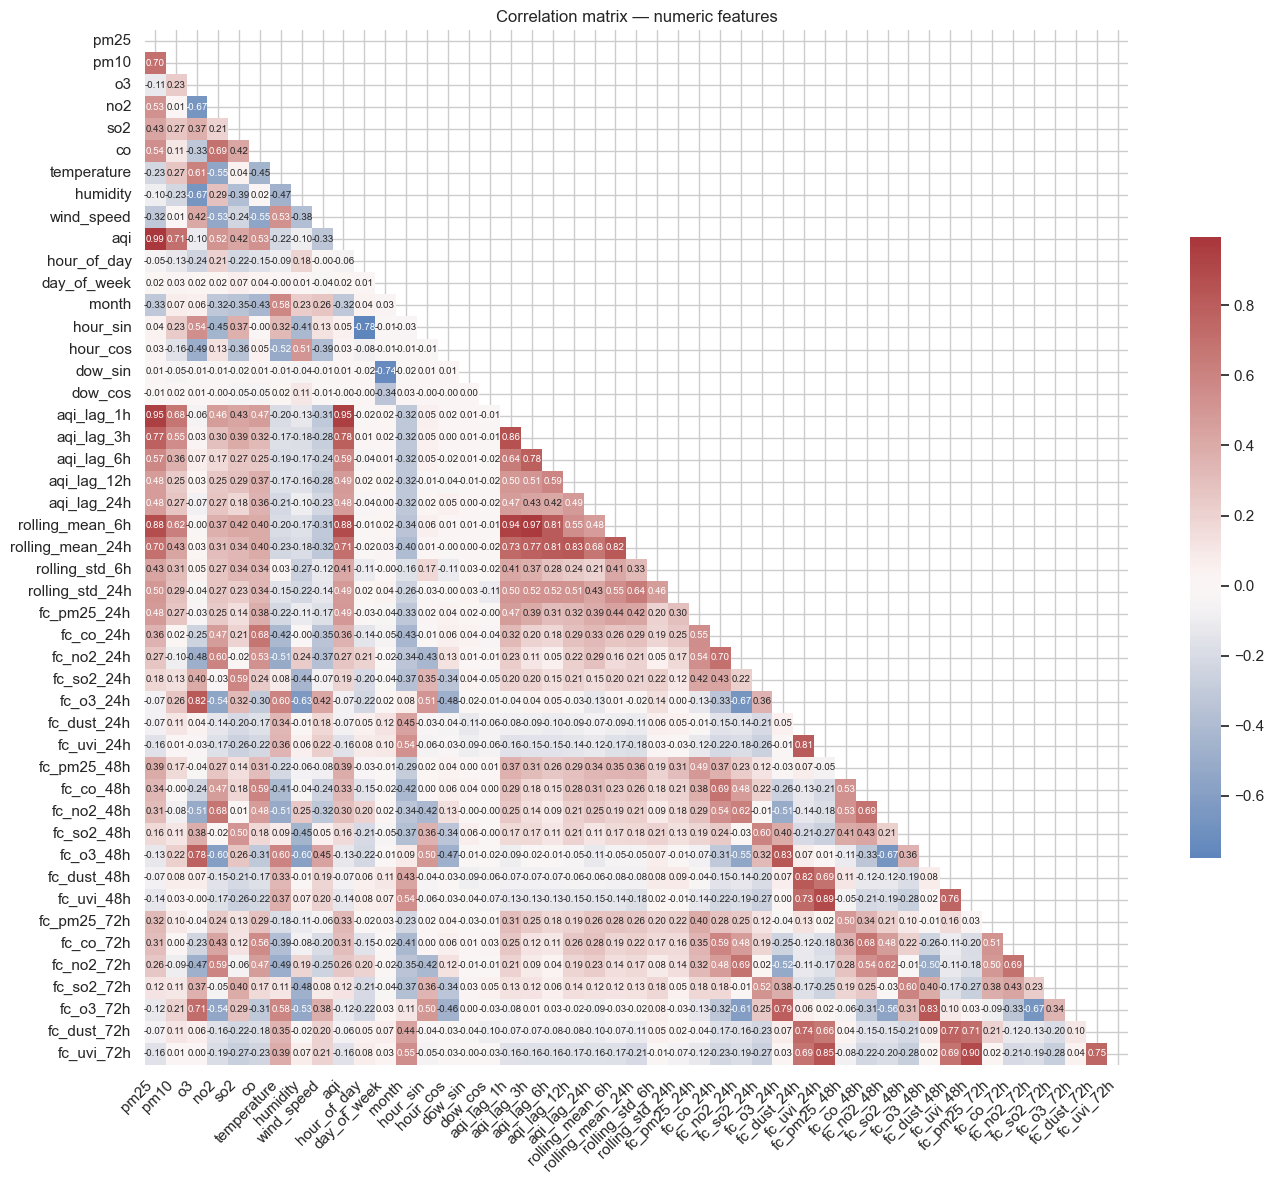

In [7]:
# Cell 5: Correlation matrix and heatmap for numeric features
num = df.select_dtypes(include=['number'])
corr = num.corr()
plt.figure(figsize=(14,12))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='vlag', center=0, annot_kws={'size':7}, cbar_kws={'shrink':0.6})
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.title('Correlation matrix — numeric features')
plt.tight_layout()
plt.show()

## 3. Missing Value Analysis

Columns with missing values: 28
                 missing_count  missing_pct
aqi_lag_24h                 24         1.00
aqi_lag_12h                 12         0.50
aqi_lag_6h                   6         0.25
aqi_lag_3h                   3         0.12
fc_co_48h                    1         0.04
fc_co_24h                    1         0.04
fc_no2_24h                   1         0.04
fc_so2_24h                   1         0.04
fc_o3_24h                    1         0.04
fc_dust_24h                  1         0.04
fc_uvi_24h                   1         0.04
fc_no2_48h                   1         0.04
rolling_std_6h               1         0.04
fc_so2_48h                   1         0.04
fc_o3_48h                    1         0.04
fc_dust_48h                  1         0.04
fc_uvi_48h                   1         0.04
fc_co_72h                    1         0.04
fc_no2_72h                   1         0.04
fc_so2_72h                   1         0.04
fc_o3_72h                    1         0.04


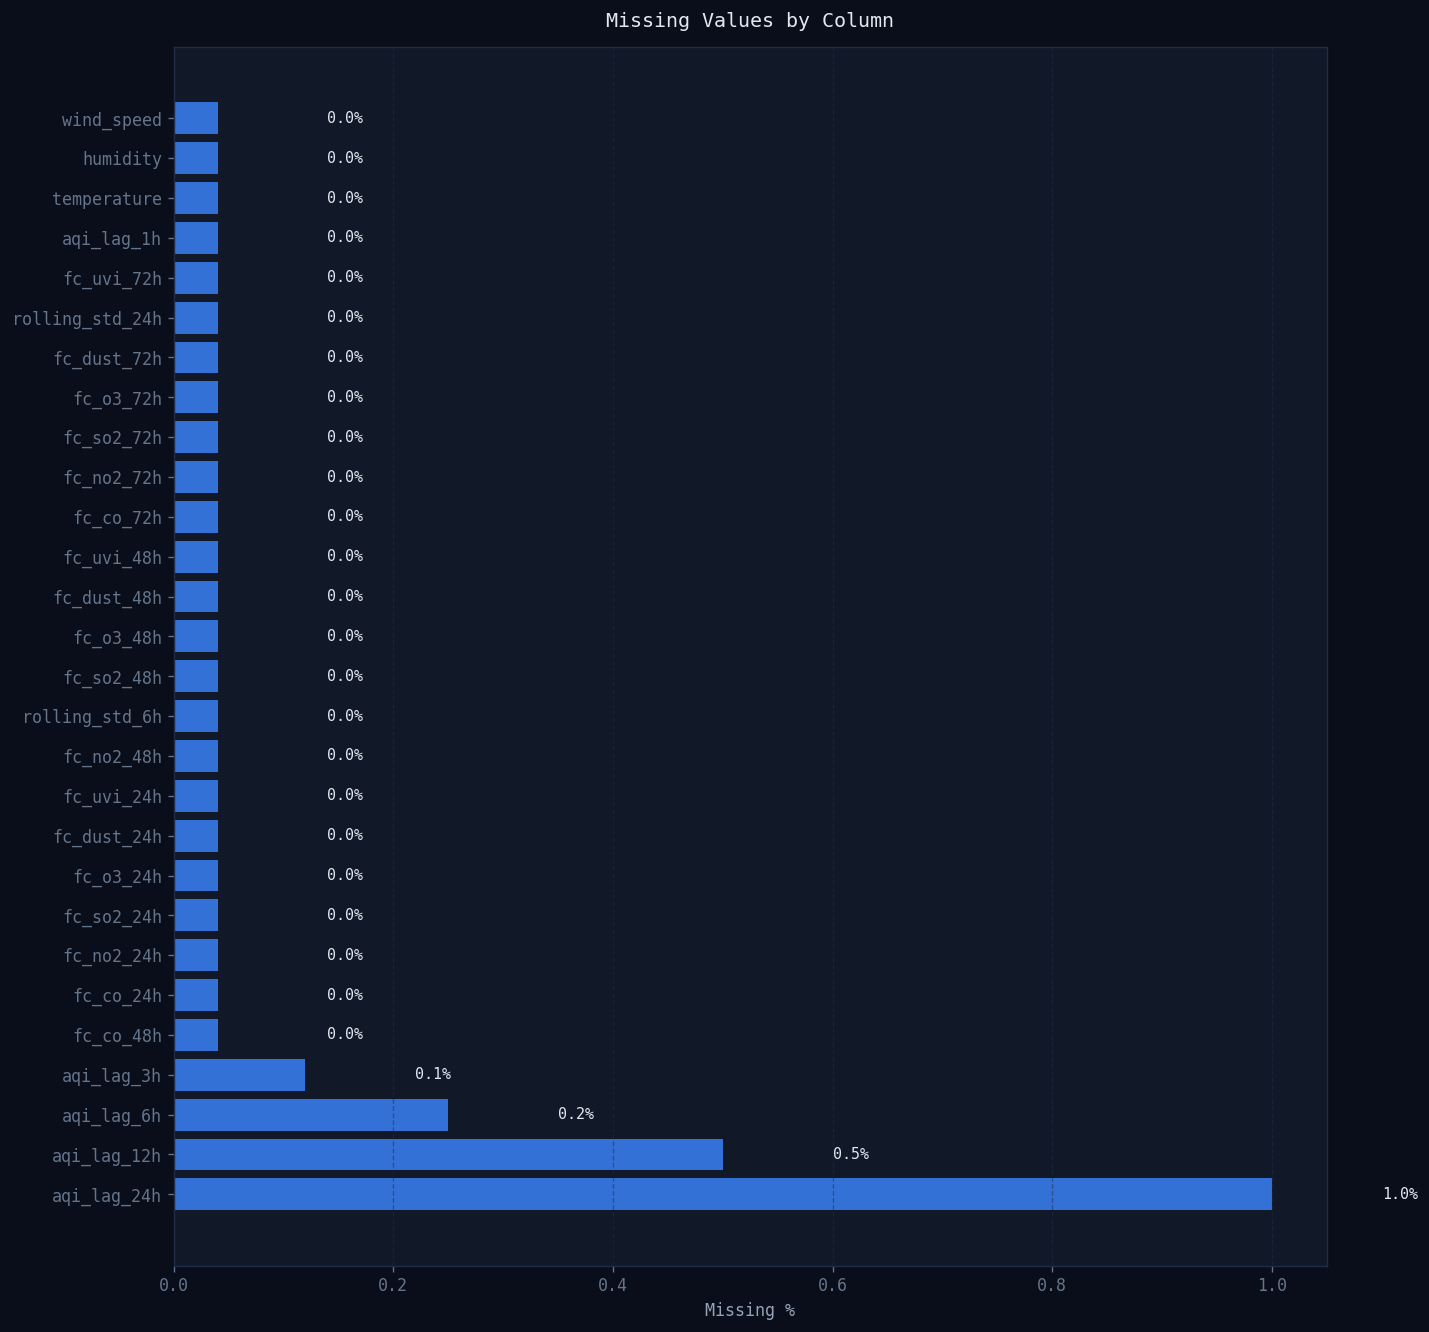

In [6]:
# ── Missing value analysis ──────────────────────────────────────────────────
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'missing_count': missing,
    'missing_pct': missing_pct
}).sort_values('missing_pct', ascending=False)
missing_df = missing_df[missing_df['missing_count'] > 0]

print(f"Columns with missing values: {len(missing_df)}")
print(missing_df.to_string())

# Plot
if not missing_df.empty:
    fig, ax = plt.subplots(figsize=(12, max(4, len(missing_df) * 0.4)))
    bars = ax.barh(missing_df.index, missing_df['missing_pct'],
                   color=ACCENT, alpha=0.85)
    ax.set_xlabel("Missing %")
    ax.set_title("Missing Values by Column", pad=12)
    ax.grid(axis='x')
    for bar, pct in zip(bars, missing_df['missing_pct']):
        ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
                f'{pct:.1f}%', va='center', fontsize=9)
    plt.tight_layout()
    plt.show()
else:
    print("\n✅ No missing values in core columns")

## 4. AQI Distribution Analysis

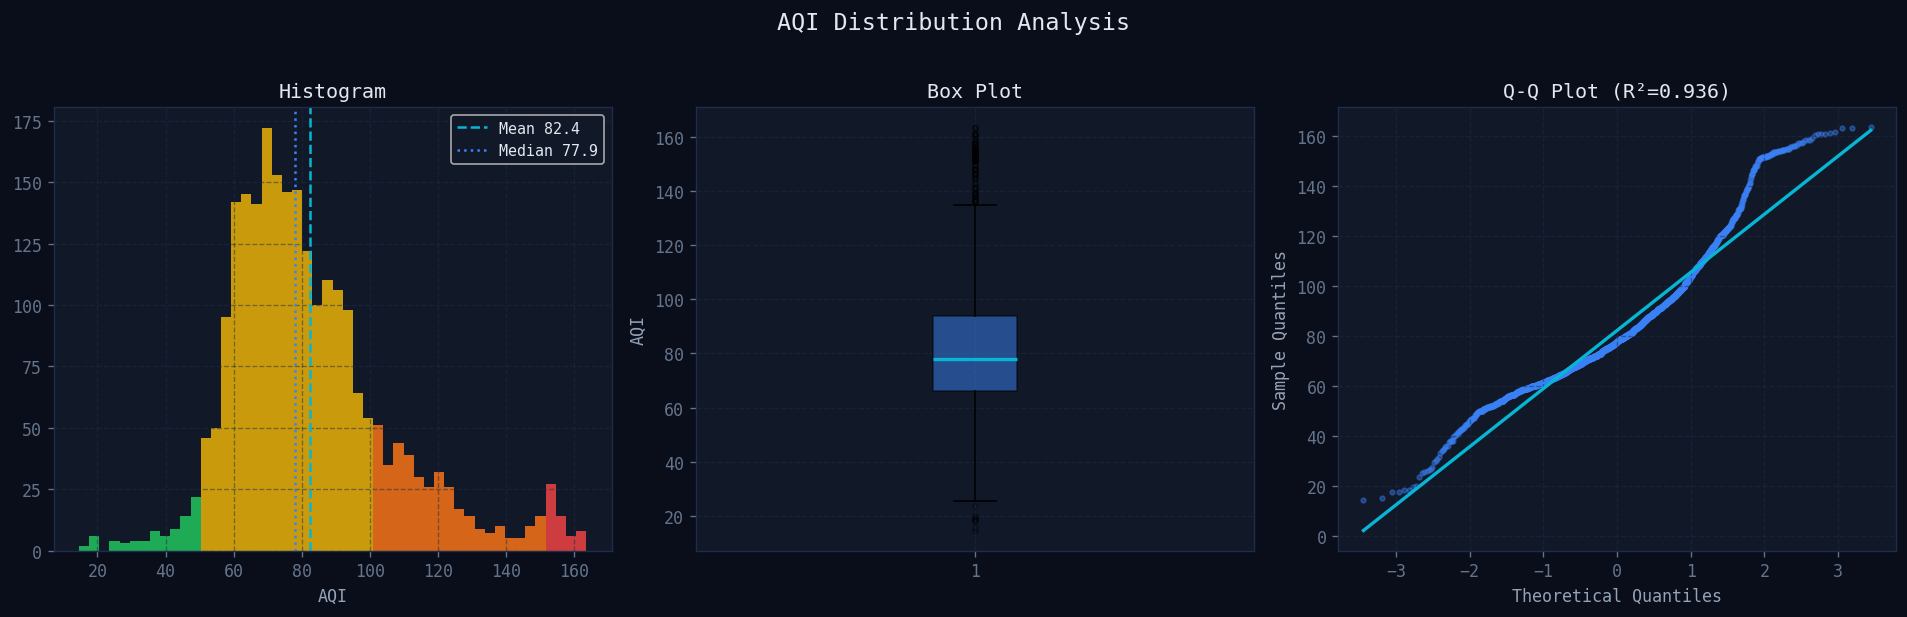


AQI Category Distribution:
----------------------------------------
  Good (≤50)                        82  (3.4%)
  Moderate (51-100)              1,889  (78.6%)
  Unhealthy SG (101-150)           365  (15.2%)
  Unhealthy (151-200)               66  (2.7%)
  Very Unhealthy (>200)              0  (0.0%)


In [7]:
# ── AQI distribution ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("AQI Distribution Analysis", fontsize=14, y=1.02)

# Histogram
ax = axes[0]
n, bins, patches = ax.hist(df['aqi'].dropna(), bins=50, edgecolor='none', alpha=0.85)
for patch, left in zip(patches, bins[:-1]):
    if left <= 50:   patch.set_facecolor(GOOD)
    elif left <= 100: patch.set_facecolor(MODERATE)
    elif left <= 150: patch.set_facecolor("#f97316")
    else:            patch.set_facecolor(BAD)
ax.axvline(df['aqi'].mean(),   color=ACCENT2, linestyle='--', lw=1.5, label=f"Mean {df['aqi'].mean():.1f}")
ax.axvline(df['aqi'].median(), color=ACCENT,  linestyle=':',  lw=1.5, label=f"Median {df['aqi'].median():.1f}")
ax.set_title("Histogram")
ax.set_xlabel("AQI")
ax.legend(fontsize=9)
ax.grid(True)

# Boxplot
ax = axes[1]
bp = ax.boxplot(df['aqi'].dropna(), vert=True, patch_artist=True,
                medianprops=dict(color=ACCENT2, lw=2),
                boxprops=dict(facecolor=ACCENT, alpha=0.5),
                flierprops=dict(marker='o', color=BAD, alpha=0.3, markersize=3))
ax.set_title("Box Plot")
ax.set_ylabel("AQI")
ax.grid(True)

# QQ Plot
ax = axes[2]
(osm, osr), (slope, intercept, r) = stats.probplot(df['aqi'].dropna(), dist="norm")
ax.scatter(osm, osr, color=ACCENT, alpha=0.4, s=8)
ax.plot(osm, slope * np.array(osm) + intercept, color=ACCENT2, lw=2)
ax.set_title(f"Q-Q Plot (R²={r**2:.3f})")
ax.set_xlabel("Theoretical Quantiles")
ax.set_ylabel("Sample Quantiles")
ax.grid(True)

plt.tight_layout()
plt.show()

# AQI category breakdown
categories = {
    'Good (≤50)':        (df['aqi'] <= 50).sum(),
    'Moderate (51-100)': ((df['aqi'] > 50)  & (df['aqi'] <= 100)).sum(),
    'Unhealthy SG (101-150)': ((df['aqi'] > 100) & (df['aqi'] <= 150)).sum(),
    'Unhealthy (151-200)': ((df['aqi'] > 150) & (df['aqi'] <= 200)).sum(),
    'Very Unhealthy (>200)': (df['aqi'] > 200).sum(),
}
print("\nAQI Category Distribution:")
print("-" * 40)
for cat, count in categories.items():
    pct = count / len(df) * 100
    print(f"  {cat:<30} {count:>5,}  ({pct:.1f}%)")

## 5. Temporal Patterns

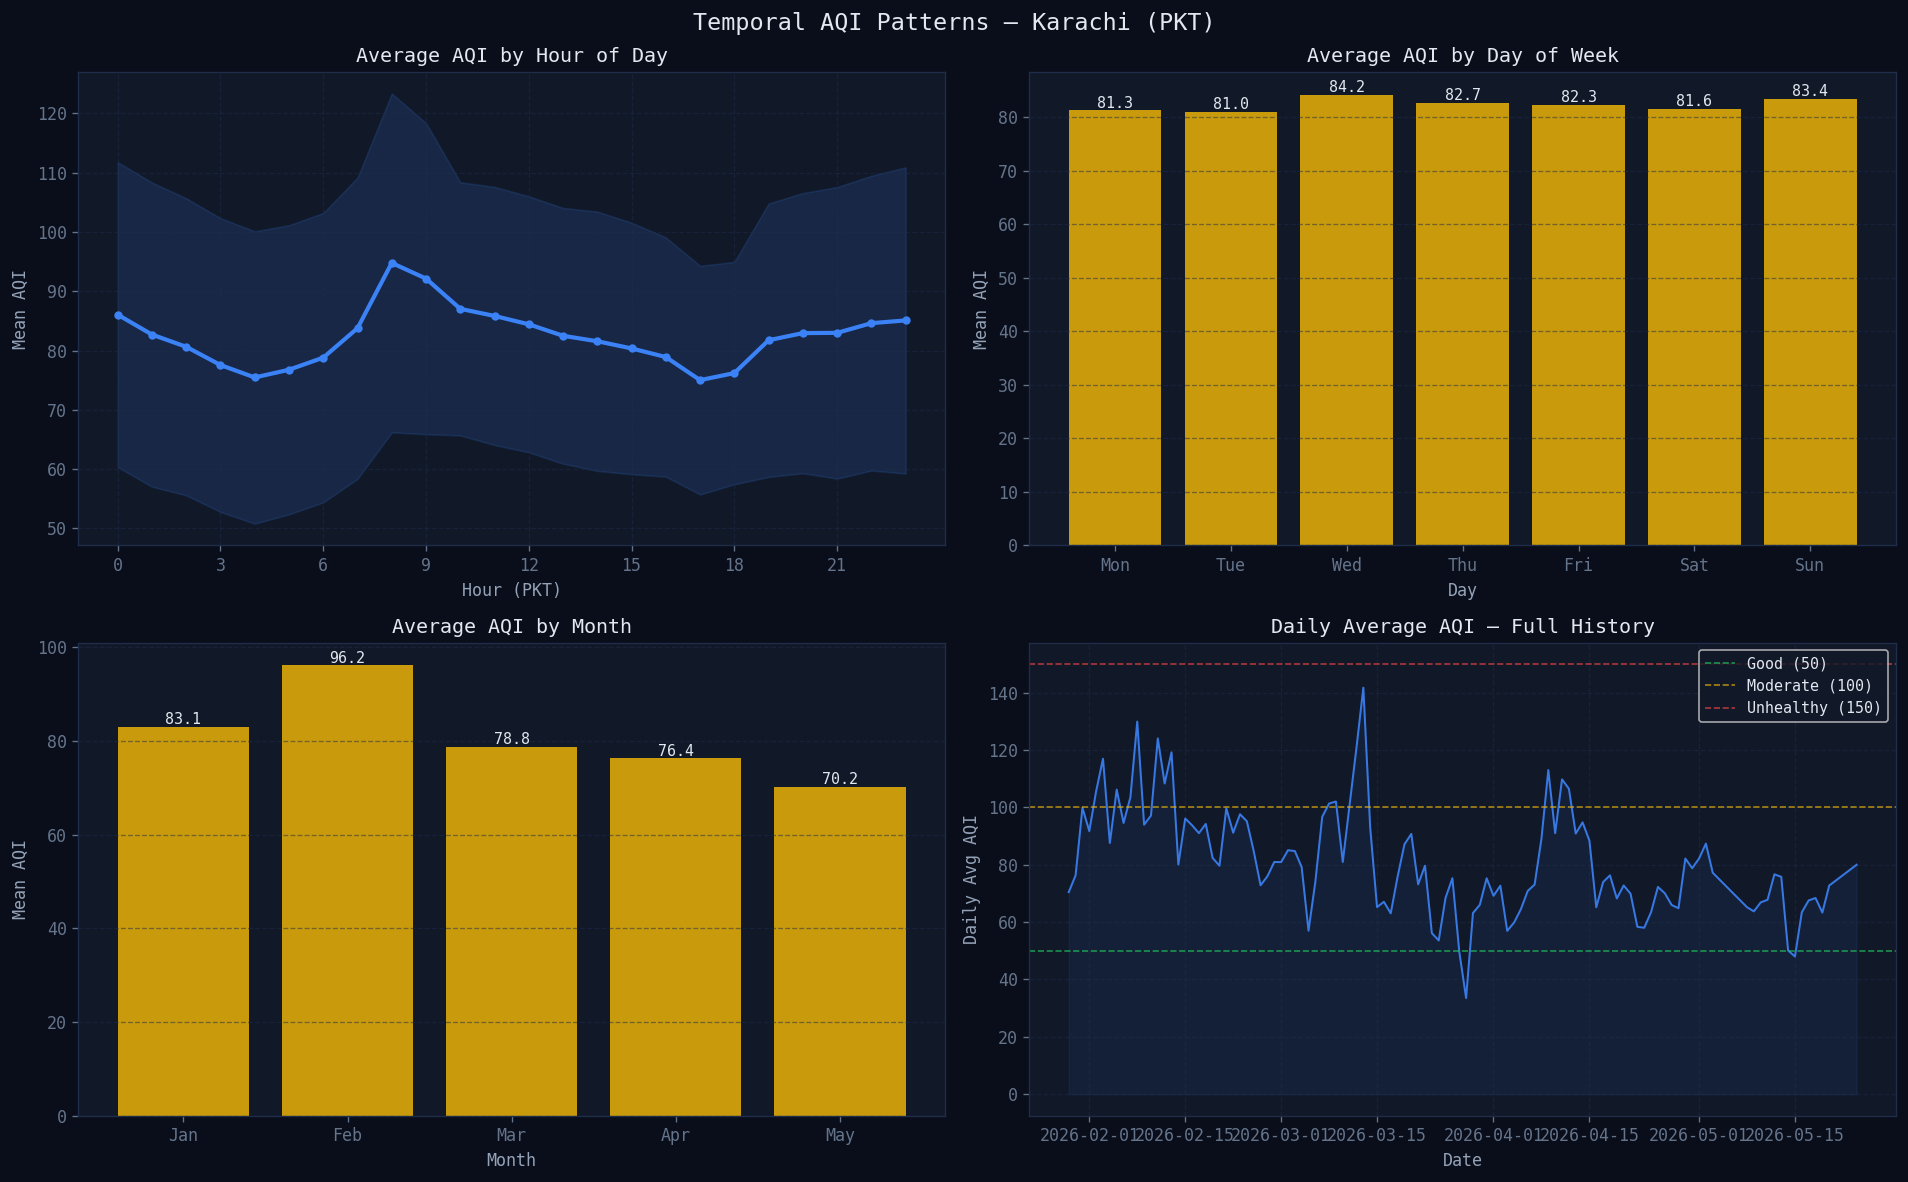

In [9]:
# ── Temporal patterns ───────────────────────────────────────────────────────
df_local = df.copy()
df_local['timestamp_pkt'] = df_local['timestamp'].dt.tz_convert('Asia/Karachi')
df_local['hour']  = df_local['timestamp_pkt'].dt.hour
df_local['dow']   = df_local['timestamp_pkt'].dt.dayofweek
df_local['month'] = df_local['timestamp_pkt'].dt.month
df_local['date']  = df_local['timestamp_pkt'].dt.date
DOW_LABELS = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
MONTH_LABELS = ['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Temporal AQI Patterns — Karachi (PKT)", fontsize=14)

# Hourly pattern
ax = axes[0, 0]
hourly = df_local.groupby('hour')['aqi'].agg(['mean', 'std'])
ax.fill_between(hourly.index,
                hourly['mean'] - hourly['std'],
                hourly['mean'] + hourly['std'],
                alpha=0.15, color=ACCENT)
ax.plot(hourly.index, hourly['mean'], color=ACCENT, lw=2.5, marker='o', ms=4)
ax.set_title("Average AQI by Hour of Day")
ax.set_xlabel("Hour (PKT)")
ax.set_ylabel("Mean AQI")
ax.set_xticks(range(0, 24, 3))
ax.grid(True)

# Day of week pattern
ax = axes[0, 1]
daily = df_local.groupby('dow')['aqi'].mean()
colors = [GOOD if v <= 50 else MODERATE if v <= 100 else BAD for v in daily]
bars = ax.bar(daily.index, daily.values, color=colors, alpha=0.85)
ax.set_title("Average AQI by Day of Week")
ax.set_xlabel("Day")
ax.set_ylabel("Mean AQI")
ax.set_xticks(range(7))
ax.set_xticklabels(DOW_LABELS)
ax.grid(axis='y')
for bar, val in zip(bars, daily.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}', ha='center', fontsize=9)

# Monthly pattern
ax = axes[1, 0]
monthly = df_local.groupby('month')['aqi'].mean()
present_months = monthly.index.tolist()
labels = [MONTH_LABELS[m-1] for m in present_months]
colors = [GOOD if v <= 50 else MODERATE if v <= 100 else BAD for v in monthly]
bars = ax.bar(range(len(present_months)), monthly.values, color=colors, alpha=0.85)
ax.set_title("Average AQI by Month")
ax.set_xlabel("Month")
ax.set_ylabel("Mean AQI")
ax.set_xticks(range(len(present_months)))
ax.set_xticklabels(labels)
ax.grid(axis='y')
for bar, val in zip(bars, monthly.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}', ha='center', fontsize=9)

# Full time series
ax = axes[1, 1]
daily_avg = df_local.groupby('date')['aqi'].mean().reset_index()
daily_avg['date'] = pd.to_datetime(daily_avg['date'])
ax.plot(daily_avg['date'], daily_avg['aqi'], color=ACCENT, lw=1.2, alpha=0.9)
ax.fill_between(daily_avg['date'], daily_avg['aqi'], alpha=0.08, color=ACCENT)
ax.axhline(50,  color=GOOD,     linestyle='--', lw=1, alpha=0.7, label='Good (50)')
ax.axhline(100, color=MODERATE, linestyle='--', lw=1, alpha=0.7, label='Moderate (100)')
ax.axhline(150, color=BAD,      linestyle='--', lw=1, alpha=0.7, label='Unhealthy (150)')
ax.set_title("Daily Average AQI — Full History")
ax.set_xlabel("Date")
ax.set_ylabel("Daily Avg AQI")
ax.legend(fontsize=9)
ax.grid(True)

plt.tight_layout()
plt.show()

## 6. Pollutant Correlation Analysis

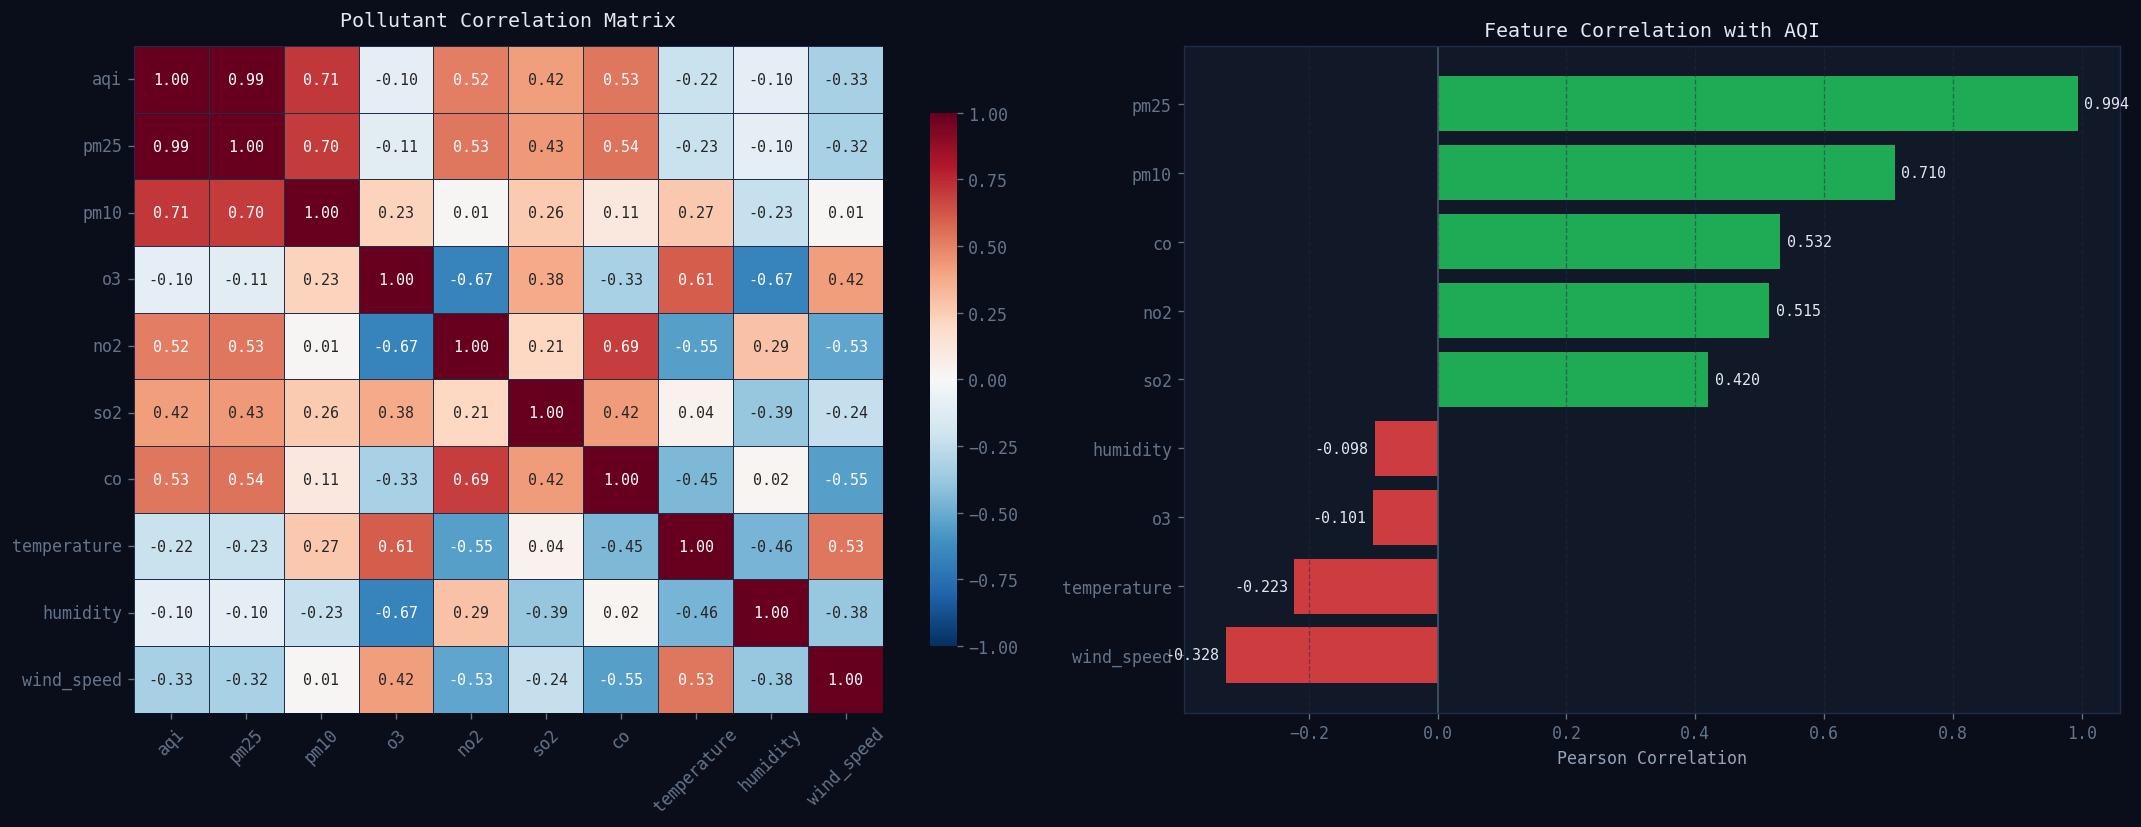


Top 5 features correlated with AQI:
pm25    0.993912
pm10    0.710209
co      0.531701
no2     0.515214
so2     0.419929


In [10]:
# ── Correlation analysis ────────────────────────────────────────────────────
pollutants = ['aqi', 'pm25', 'pm10', 'o3', 'no2', 'so2', 'co',
              'temperature', 'humidity', 'wind_speed']

corr_matrix = df[pollutants].corr()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Full heatmap
ax = axes[0]
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask, k=1)] = True
sns.heatmap(
    corr_matrix,
    ax=ax,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    linecolor='#1e2d4a',
    annot_kws={"size": 9},
    cbar_kws={"shrink": 0.8}
)
ax.set_title("Pollutant Correlation Matrix", pad=12)
ax.tick_params(axis='x', rotation=45)

# AQI correlation bar chart
ax = axes[1]
aqi_corr = corr_matrix['aqi'].drop('aqi').sort_values(ascending=True)
colors = [GOOD if v > 0 else BAD for v in aqi_corr.values]
bars = ax.barh(aqi_corr.index, aqi_corr.values, color=colors, alpha=0.85)
ax.axvline(0, color='#475569', lw=1)
ax.set_title("Feature Correlation with AQI")
ax.set_xlabel("Pearson Correlation")
ax.grid(axis='x')
for bar, val in zip(bars, aqi_corr.values):
    ax.text(val + (0.01 if val >= 0 else -0.01),
            bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center',
            ha='left' if val >= 0 else 'right', fontsize=9)

plt.tight_layout()
plt.show()

print("\nTop 5 features correlated with AQI:")
print(corr_matrix['aqi'].drop('aqi').abs().sort_values(ascending=False).head(5).to_string())

## 7. Feature Engineering Validation

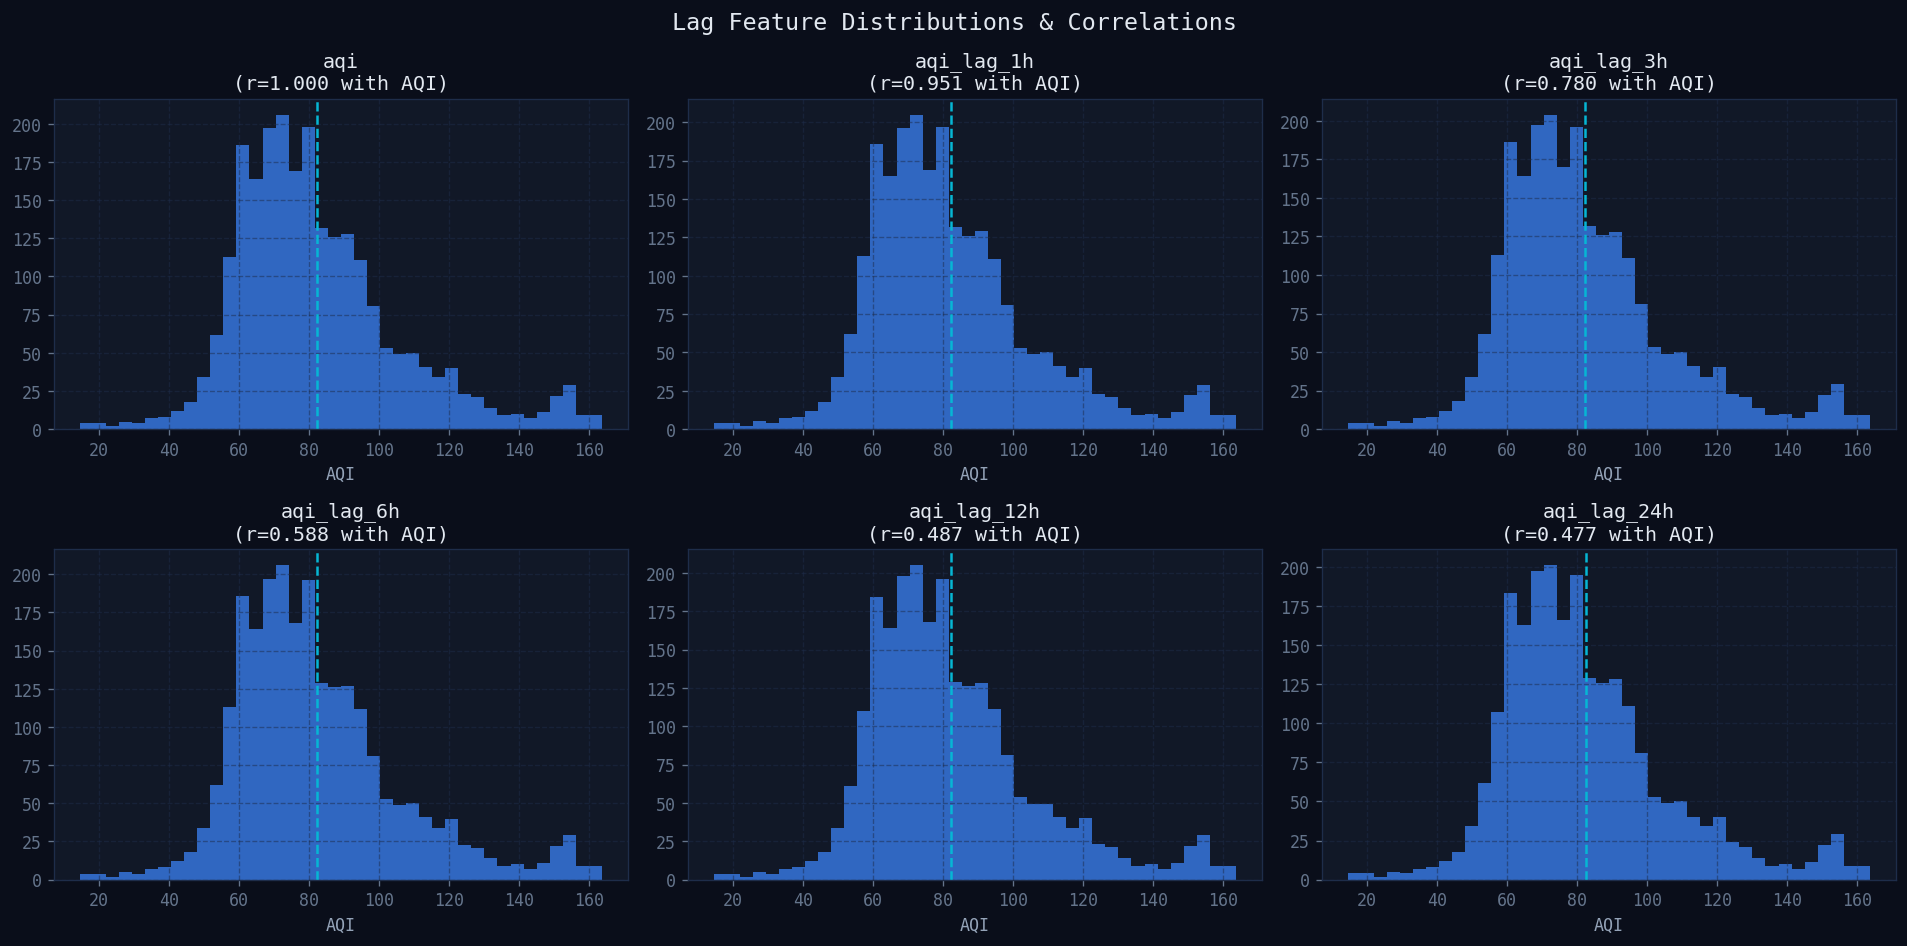


Lag Feature Correlations with AQI:
-----------------------------------
  aqi_lag_1h           r = 0.9511
  aqi_lag_3h           r = 0.7798
  aqi_lag_6h           r = 0.5878
  aqi_lag_12h          r = 0.4871
  aqi_lag_24h          r = 0.4769


In [11]:
# ── Lag feature validation ──────────────────────────────────────────────────
lag_cols = ['aqi', 'aqi_lag_1h', 'aqi_lag_3h', 'aqi_lag_6h',
            'aqi_lag_12h', 'aqi_lag_24h']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle("Lag Feature Distributions & Correlations", fontsize=14)
axes = axes.flatten()

for i, col in enumerate(lag_cols):
    ax = axes[i]
    data = df[col].dropna()
    ax.hist(data, bins=40, color=ACCENT, alpha=0.75, edgecolor='none')
    ax.axvline(data.mean(), color=ACCENT2, linestyle='--', lw=1.5)
    corr_with_aqi = df[['aqi', col]].dropna().corr().iloc[0, 1]
    ax.set_title(f"{col}\n(r={corr_with_aqi:.3f} with AQI)")
    ax.set_xlabel("AQI")
    ax.grid(True)

plt.tight_layout()
plt.show()

# Lag correlation summary
print("\nLag Feature Correlations with AQI:")
print("-" * 35)
for col in lag_cols[1:]:
    corr = df[['aqi', col]].dropna().corr().iloc[0, 1]
    print(f"  {col:<20} r = {corr:.4f}")

## 8. Forecast Feature Coverage

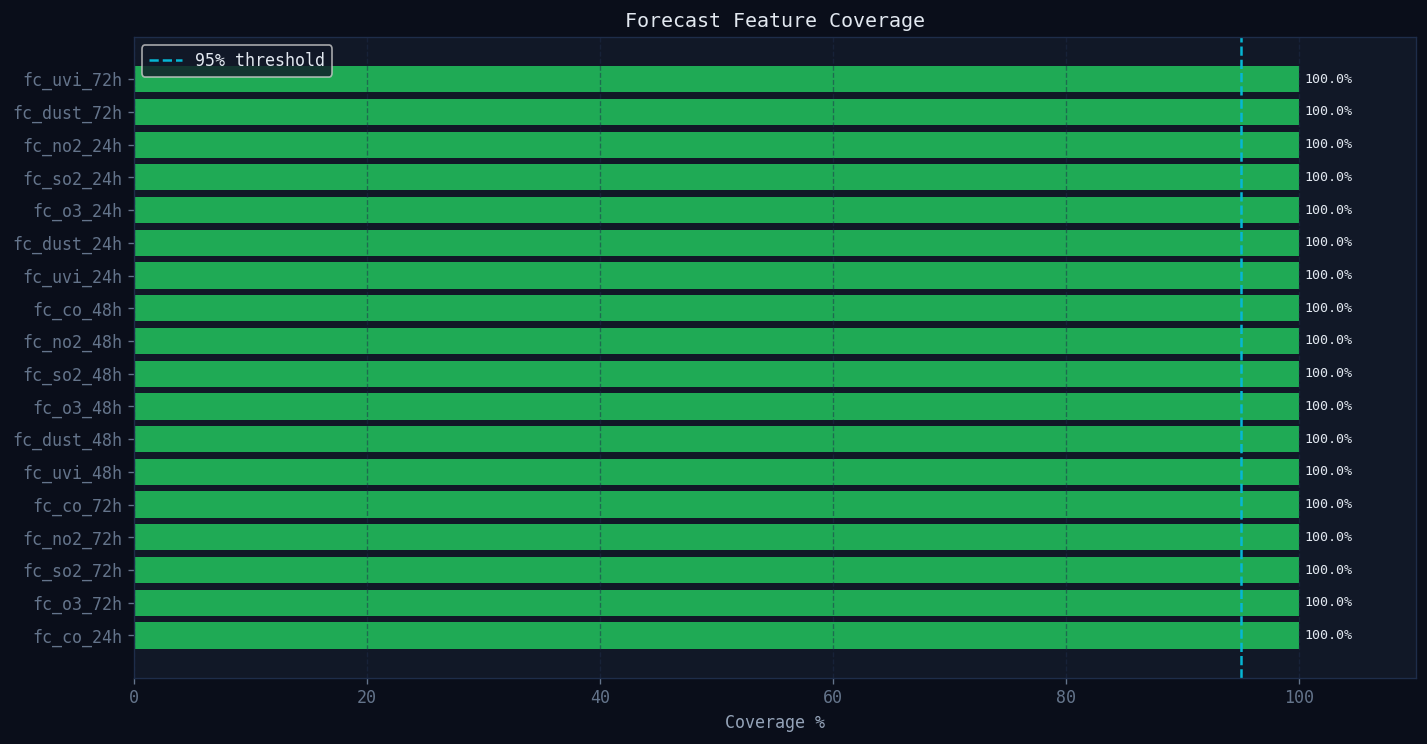


Forecast features with ≥95% coverage: 18/18


In [12]:
# ── Forecast feature coverage ───────────────────────────────────────────────
fc_cols = [c for c in df.columns if c.startswith('fc_')]

coverage = df[fc_cols].notna().mean() * 100
coverage_df = pd.DataFrame({'feature': coverage.index,
                             'coverage_pct': coverage.values})
coverage_df = coverage_df.sort_values('coverage_pct', ascending=True)

fig, ax = plt.subplots(figsize=(12, max(5, len(fc_cols) * 0.35)))
colors = [GOOD if v >= 95 else MODERATE if v >= 50 else BAD
          for v in coverage_df['coverage_pct']]
bars = ax.barh(coverage_df['feature'], coverage_df['coverage_pct'],
               color=colors, alpha=0.85)
ax.axvline(95, color=ACCENT2, linestyle='--', lw=1.5, label='95% threshold')
ax.set_xlabel("Coverage %")
ax.set_title("Forecast Feature Coverage")
ax.set_xlim(0, 110)
ax.legend()
ax.grid(axis='x')
for bar, val in zip(bars, coverage_df['coverage_pct']):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=8)

plt.tight_layout()
plt.show()

print(f"\nForecast features with ≥95% coverage: "
      f"{(coverage_df['coverage_pct'] >= 95).sum()}/{len(coverage_df)}")

## 9. Target Variable Analysis

Horizon 24h — Valid rows: 2,184  Mean: 83.6  Std: 24.2
Horizon 48h — Valid rows: 2,136  Mean: 83.6  Std: 24.3
Horizon 72h — Valid rows: 2,088  Mean: 83.4  Std: 24.5


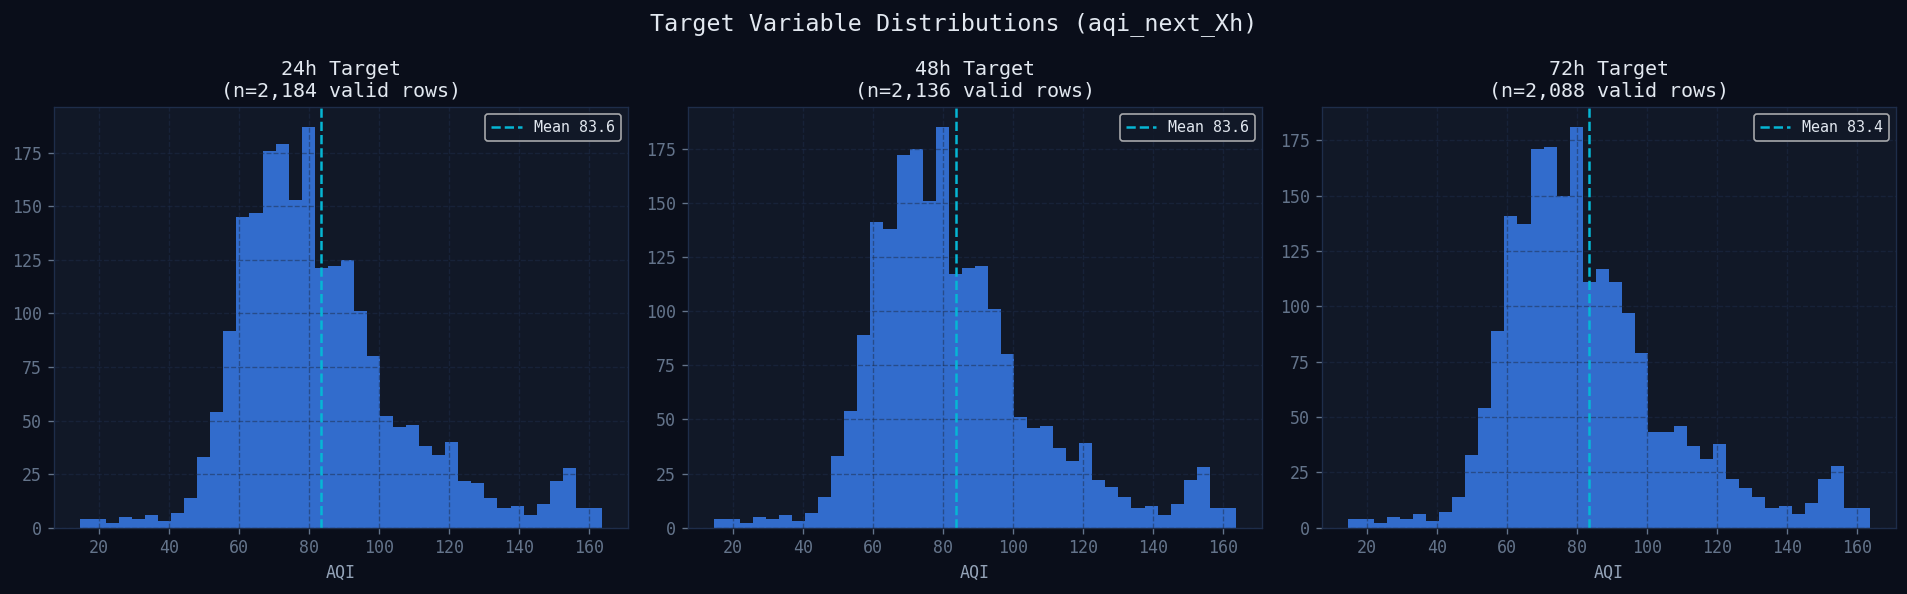

In [13]:
# ── Target variable analysis ─────────────────────────────────────────────────
from aqi_feature_utils import build_training_frame

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Target Variable Distributions (aqi_next_Xh)", fontsize=14)

for i, horizon in enumerate([24, 48, 72]):
    ax = axes[i]
    frame = build_training_frame(df, horizon)
    target_col = f'aqi_next_{horizon}h'

    # Filter valid targets
    frame = frame.dropna(subset=[target_col])
    target_ts = frame['timestamp'].shift(-horizon)
    valid = (target_ts - frame['timestamp']).dt.total_seconds() / 3600 == horizon
    frame = frame[valid]

    target = frame[target_col].dropna()
    ax.hist(target, bins=40, color=ACCENT, alpha=0.8, edgecolor='none')
    ax.axvline(target.mean(), color=ACCENT2, linestyle='--',
               lw=1.5, label=f'Mean {target.mean():.1f}')
    ax.set_title(f"{horizon}h Target\n(n={len(target):,} valid rows)")
    ax.set_xlabel("AQI")
    ax.legend(fontsize=9)
    ax.grid(True)

    print(f"Horizon {horizon}h — Valid rows: {len(target):,}  "
          f"Mean: {target.mean():.1f}  Std: {target.std():.1f}")

plt.tight_layout()
plt.show()

## 10. Timestamp Gap Analysis

Timestamp Gap Distribution:
----------------------------------------
  1h gap: 2,301 occurrences (95.8%)
  2h gap:    46 occurrences (1.9%)
  3h gap:    34 occurrences (1.4%)
  4h gap:    17 occurrences (0.7%)
  114h gap:     1 occurrences (0.0%)
  5h gap:     1 occurrences (0.0%)
  95h gap:     1 occurrences (0.0%)

✅ Expected 1h gaps : 2,301 (95.8%)
⚠️  Non-1h gaps     : 100 (4.2%)


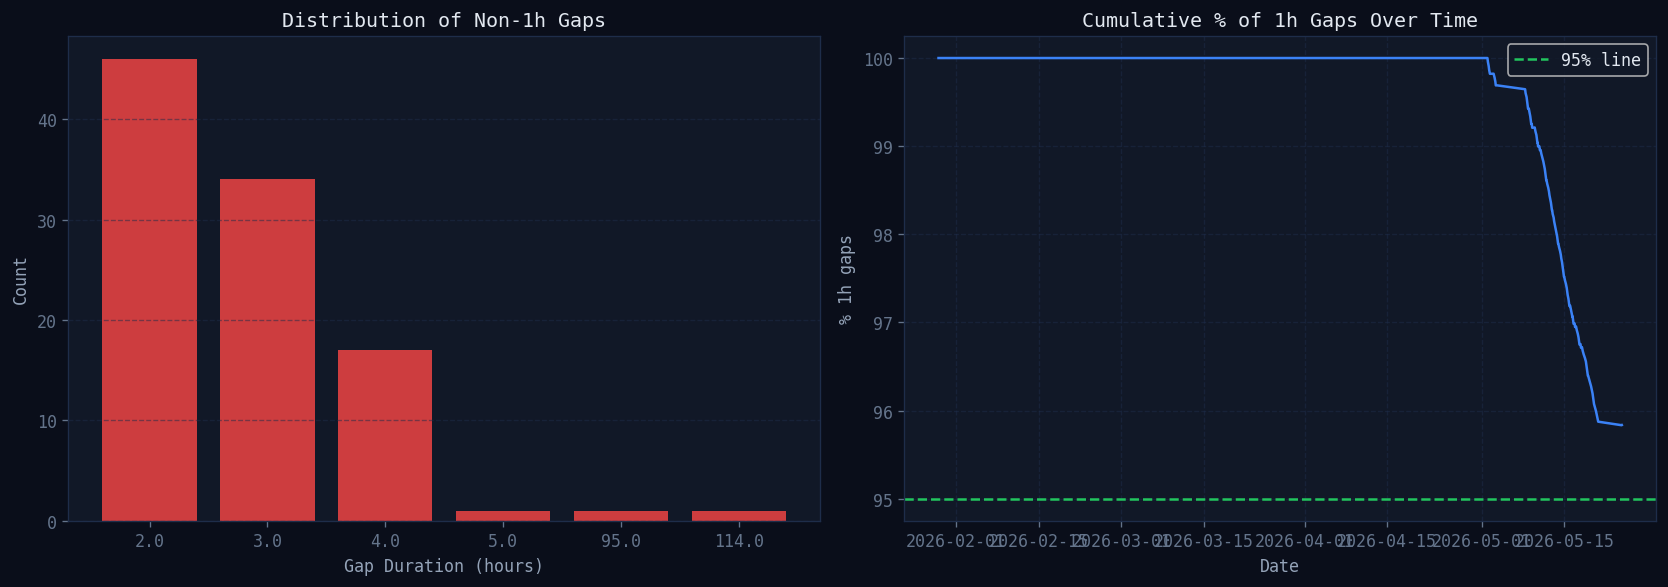


💡 Note: Non-1h gaps cause shift(-24) to produce incorrect targets.
   These rows are filtered in training_pipeline.py using exact-horizon validation.


In [14]:
# ── Timestamp gap analysis ───────────────────────────────────────────────────
time_diffs = df['timestamp'].diff().dropna()
hours_diff = time_diffs.dt.total_seconds() / 3600

print("Timestamp Gap Distribution:")
print("-" * 40)
gap_counts = hours_diff.value_counts().head(10)
for gap, count in gap_counts.items():
    pct = count / len(hours_diff) * 100
    print(f"  {gap:.0f}h gap: {count:>5,} occurrences ({pct:.1f}%)")

expected_1h = (hours_diff == 1).sum()
non_1h      = (hours_diff != 1).sum()
print(f"\n✅ Expected 1h gaps : {expected_1h:,} ({expected_1h/len(hours_diff)*100:.1f}%)")
print(f"⚠️  Non-1h gaps     : {non_1h:,} ({non_1h/len(hours_diff)*100:.1f}%)")

# Plot gap distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
gap_plot = hours_diff[hours_diff > 1].value_counts().head(15).sort_index()
ax.bar(gap_plot.index.astype(str), gap_plot.values, color=BAD, alpha=0.85)
ax.set_title("Distribution of Non-1h Gaps")
ax.set_xlabel("Gap Duration (hours)")
ax.set_ylabel("Count")
ax.grid(axis='y')

ax = axes[1]
cumulative = (hours_diff == 1).cumsum() / np.arange(1, len(hours_diff)+1) * 100
ax.plot(df['timestamp'].iloc[1:], cumulative.values, color=ACCENT, lw=1.5)
ax.axhline(95, color=GOOD, linestyle='--', lw=1.5, label='95% line')
ax.set_title("Cumulative % of 1h Gaps Over Time")
ax.set_xlabel("Date")
ax.set_ylabel("% 1h gaps")
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()

print("\n💡 Note: Non-1h gaps cause shift(-24) to produce incorrect targets.")
print("   These rows are filtered in training_pipeline.py using exact-horizon validation.")

## 11. Rolling Feature Analysis

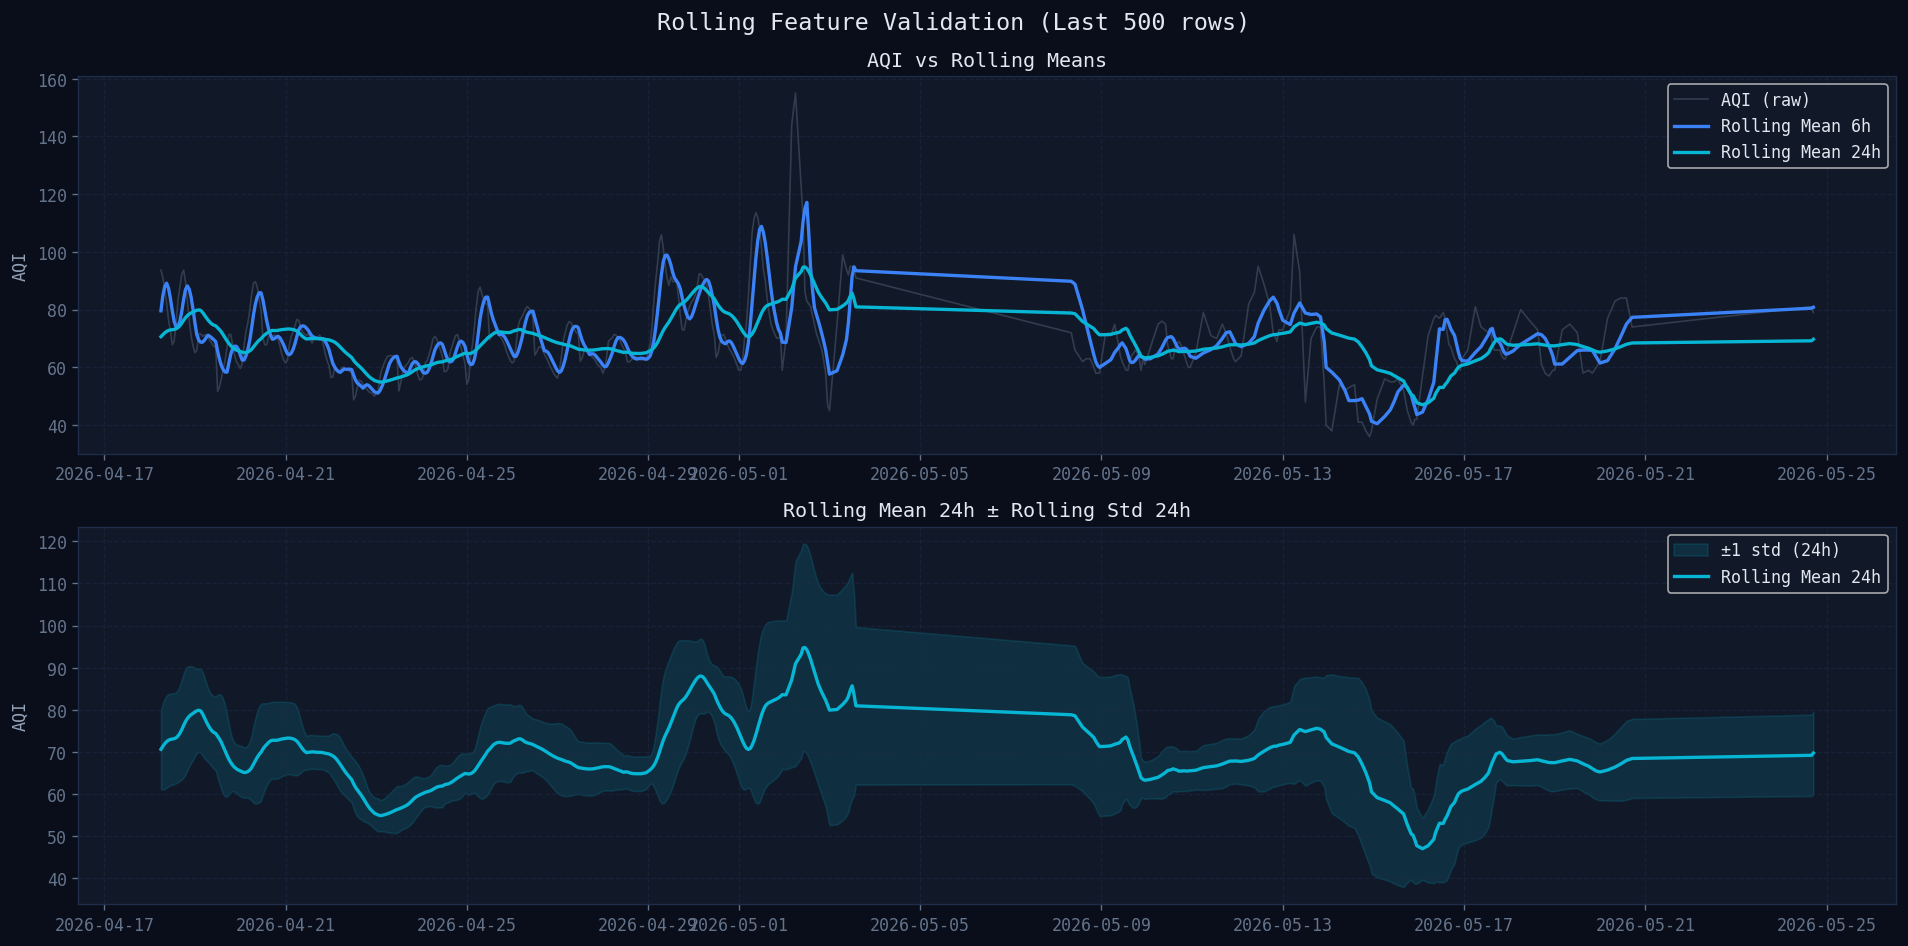

Rolling feature correlations with AQI:
  rolling_mean_6h           r = 0.8844
  rolling_mean_24h          r = 0.7076
  rolling_std_6h            r = 0.4116
  rolling_std_24h           r = 0.4873


In [15]:
# ── Rolling features ─────────────────────────────────────────────────────────
rolling_cols = ['aqi', 'rolling_mean_6h', 'rolling_mean_24h',
                'rolling_std_6h', 'rolling_std_24h']

sample = df.tail(500).copy()

fig, axes = plt.subplots(2, 1, figsize=(16, 8))
fig.suptitle("Rolling Feature Validation (Last 500 rows)", fontsize=14)

# Rolling means vs AQI
ax = axes[0]
ax.plot(sample['timestamp'], sample['aqi'],
        color='#475569', lw=1, alpha=0.6, label='AQI (raw)')
ax.plot(sample['timestamp'], sample['rolling_mean_6h'],
        color=ACCENT, lw=2, label='Rolling Mean 6h')
ax.plot(sample['timestamp'], sample['rolling_mean_24h'],
        color=ACCENT2, lw=2, label='Rolling Mean 24h')
ax.set_title("AQI vs Rolling Means")
ax.set_ylabel("AQI")
ax.legend()
ax.grid(True)

# Rolling stds
ax = axes[1]
ax.fill_between(sample['timestamp'],
                sample['rolling_mean_24h'] - sample['rolling_std_24h'],
                sample['rolling_mean_24h'] + sample['rolling_std_24h'],
                alpha=0.15, color=ACCENT2, label='±1 std (24h)')
ax.plot(sample['timestamp'], sample['rolling_mean_24h'],
        color=ACCENT2, lw=2, label='Rolling Mean 24h')
ax.set_title("Rolling Mean 24h ± Rolling Std 24h")
ax.set_ylabel("AQI")
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()

print("Rolling feature correlations with AQI:")
for col in rolling_cols[1:]:
    corr = df[['aqi', col]].dropna().corr().iloc[0, 1]
    print(f"  {col:<25} r = {corr:.4f}")

## 12. Key Insights & Conclusions

In [16]:
# ── Summary insights ─────────────────────────────────────────────────────────
aqi_mean   = df['aqi'].mean()
aqi_std    = df['aqi'].std()
pm25_corr  = df[['aqi','pm25']].corr().iloc[0,1]
good_pct   = (df['aqi'] <= 50).mean() * 100
mod_pct    = ((df['aqi'] > 50) & (df['aqi'] <= 100)).mean() * 100
bad_pct    = (df['aqi'] > 100).mean() * 100
peak_hour  = df_local.groupby('hour')['aqi'].mean().idxmax()
clean_hour = df_local.groupby('hour')['aqi'].mean().idxmin()
total_gaps = (hours_diff != 1).sum()

print("=" * 65)
print("  KARACHI AQI EDA — KEY INSIGHTS SUMMARY")
print("=" * 65)
print(f"""
📊 DATASET
   • {len(df):,} hourly observations from {df['timestamp'].min().date()} to {df['timestamp'].max().date()}
   • {len(df.columns)} engineered features including lags, rolling stats, forecasts
   • {total_gaps} timestamp gaps detected — filtered in training pipeline

🌫️  AQI STATISTICS
   • Mean AQI     : {aqi_mean:.1f} (Moderate category)
   • Std Dev      : {aqi_std:.1f}
   • Good days    : {good_pct:.1f}%
   • Moderate     : {mod_pct:.1f}%
   • Unhealthy+   : {bad_pct:.1f}%

🔬 POLLUTANT INSIGHTS
   • PM2.5 correlation with AQI : {pm25_corr:.3f} (dominant predictor)
   • Peak pollution hour (PKT)  : {peak_hour}:00
   • Cleanest hour (PKT)        : {clean_hour}:00

⚙️  FEATURE ENGINEERING
   • Lag features (1h,3h,6h,12h,24h) show strong autocorrelation
   • Rolling statistics smooth out hourly noise
   • Cyclical time encodings (sin/cos) capture diurnal patterns
   • Forecast features (Open-Meteo 7-day) provide forward-looking signal

🎯 MODELLING IMPLICATIONS
   • Timestamp gaps corrupt shift(-24) targets → exact-horizon filtering required
   • Seasonal distribution shift (winter vs summer) → 92-day rolling window
   • fc_pm25 removed to prevent target leakage via EPA formula
   • Random Forest outperforms Ridge/XGBoost/LSTM on this dataset

📈 FINAL MODEL METRICS
   • 24h horizon : R² = 0.24,  RMSE = 10.33
   • 48h horizon : R² = 0.33,  RMSE = 9.59
   • 72h horizon : R² = 0.23,  RMSE = 10.31
""")
print("=" * 65)

  KARACHI AQI EDA — KEY INSIGHTS SUMMARY

📊 DATASET
   • 2,402 hourly observations from 2026-01-29 to 2026-05-24
   • 45 engineered features including lags, rolling stats, forecasts
   • 100 timestamp gaps detected — filtered in training pipeline

🌫️  AQI STATISTICS
   • Mean AQI     : 82.4 (Moderate category)
   • Std Dev      : 24.0
   • Good days    : 3.4%
   • Moderate     : 78.6%
   • Unhealthy+   : 17.9%

🔬 POLLUTANT INSIGHTS
   • PM2.5 correlation with AQI : 0.994 (dominant predictor)
   • Peak pollution hour (PKT)  : 8:00
   • Cleanest hour (PKT)        : 17:00

⚙️  FEATURE ENGINEERING
   • Lag features (1h,3h,6h,12h,24h) show strong autocorrelation
   • Rolling statistics smooth out hourly noise
   • Cyclical time encodings (sin/cos) capture diurnal patterns
   • Forecast features (Open-Meteo 7-day) provide forward-looking signal

🎯 MODELLING IMPLICATIONS
   • Timestamp gaps corrupt shift(-24) targets → exact-horizon filtering required
   • Seasonal distribution shift (winter 